# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [2]:
STUDENT_NAME = "PHẠM NGỌC THỊNH"  # TODO: Họ và tên
STUDENT_ID = "25820200137"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: PHẠM NGỌC THỊNH (25820200137)


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\DELL\Documents\Khoahe_MLIOT\BAI_TAP\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.


logits có thể hiểu là "điểm số chưa chuẩn hóa" (unnormalized scores) mà mô hình gán cho mỗi lớp. Softmax chỉ là bước cuối để biến các điểm số này thành phân phối xác suất trên các lớp. Là một funtion chuyển đổi(transform) một vector các giá trị đầu ra (logits) thành một phân phối xác suất, trong đó mỗi giá trị nằm trong khoảng (0,1) và tổng tất cả bằng 1. Nhờ đó, các giá trị có thể được diễn giải như xác suất mô hình gán cho từng lớp
# Hàm Softmax

Với vector đầu vào:

$$
\mathbf{z} = [z_1, z_2, \ldots, z_n]
$$

Giá trị **Softmax** của phần tử thứ $i$ được tính theo công thức:

$$
\mathrm{softmax}(z_i)=\frac{e^{z_i}}{\sum_{j=1}^{n}e^{z_j}}
$$

Trong đó:

- $e$ là hằng số Euler ($e \approx 2.71828$).
- Mẫu số là tổng các giá trị $e^{z_j}$ của toàn bộ phần tử trong vector.
- Tổng các giá trị sau khi áp dụng Softmax luôn bằng **1**, vì vậy Softmax thường được sử dụng để chuyển đầu ra của mô hình thành phân phối xác suất.

## Ví dụ

Cho vector:

$$
\mathbf{z}=[1.0,\;2.0,\;3.0]
$$

Ta có:

$$
e^1 \approx 2.718,\qquad
e^2 \approx 7.389,\qquad
e^3 \approx 20.086
$$

Tổng:

$$
2.718 + 7.389 + 20.086 = 30.193
$$

Kết quả:

$$
\mathrm{Softmax}(\mathbf{z})
=
\left[
\frac{2.718}{30.193},
\frac{7.389}{30.193},
\frac{20.086}{30.193}
\right]
\approx
[0.09,\;0.24,\;0.67]
$$

Hay:

$$
[1.0,\;2.0,\;3.0]
\;\longrightarrow\;
\mathrm{Softmax}
\approx
[0.09,\;0.24,\;0.67]
$$
## Minh họa hàm Softmax

![Cách hoạt động của Softmax](../../image/cach-hoat-dong-softmax.jpeg)
## ứng dung hàm Softmax

<div align="center">
    <img src="../../image/application_softmax.jpeg" width="500">
    <p><b>Hình 1.</b> Kết quả sau khi áp dụng hàm Softmax.</p>
</div>

In [4]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [64]:
# TODO N1
row_wise_maximum = np.max(logits, axis=1, keepdims=True)
# print(row_wise_maximum)
shifted_logits = logits - row_wise_maximum
# print(shifted_logits)
exp_logits = np.exp(shifted_logits)
# print(exp_logits)
class_probabilities =exp_logits / np.sum(exp_logits,axis=1,keepdims=True) #là xác suất của từng class sau khi áp dụng softmax.                                                                     
# print(class_probabilities)
predicted_classes = np.argmax(class_probabilities, axis=1)#là class được dự đoán, tức class có xác suất lớn nhất.
# print(predicted_classes)
confidence_scores = np.max(class_probabilities, axis=1) #là độ tin cậy của dự đoán, chính là xác suất lớn nhất của mỗi mẫu.
# print(confidence_scores)


In [6]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [7]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

## Chuẩn hóa dữ liệu (Feature Scaling)

- **`train_feature_mean`**: Vector chứa giá trị trung bình của từng feature trên tập **train**.
- **`train_feature_std`**: Vector chứa độ lệch chuẩn của từng feature trên tập **train**.
- **`X_train_scaled`**: Tập train sau khi được chuẩn hóa.
- **`X_val_scaled`**: Tập validation sau khi được chuẩn hóa bằng **mean** và **standard deviation** của tập train. **Không** tính lại mean hoặc standard deviation trên tập validation để tránh hiện tượng **data leakage**.

### Công thức chuẩn hóa

$$
x_{\text{scaled}} = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}
$$

Trong đó:

- $x$: Giá trị gốc của feature.
- $\mu_{\text{train}}$: Giá trị trung bình của feature trên tập train.
- $\sigma_{\text{train}}$: Độ lệch chuẩn của feature trên tập train.
- $x_{\text{scaled}}$: Giá trị của feature sau khi chuẩn hóa.

In [8]:
# TODO N2
train_feature_mean = X_train.mean(axis=0)
train_feature_std = X_train.std(axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [9]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [10]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [ ]:
# TODO N3
correct_mask = predicted_classes ==true_labels
high_confidence_mask =confidence_scores >= confidence_threshold
review_mask = ~(correct_mask & high_confidence_mask)
review_indices =np.where(review_mask)[0]

## Ý nghĩa

### `correct_mask`: mẫu nào được dự đoán đúng.

```python
correct_mask = predicted_classes == true_labels
```

**Ví dụ:**

```python
predicted_classes = np.array([0, 1, 2, 1])
true_labels        = np.array([0, 2, 2, 1])

correct_mask
# [ True False  True  True]
```

---

### `high_confidence_mask`: mẫu nào có độ tin cậy ≥ 0.70.

```python
high_confidence_mask = confidence_scores >= confidence_threshold
```

**Ví dụ:**

```python
confidence_scores = np.array([0.95, 0.45, 0.83, 0.68])

high_confidence_mask
# [ True False  True False]
```

---

### `review_mask`: những mẫu cần xem lại (độ tin cậy < 0.70).

```python
review_mask = ~high_confidence_mask
```

**Kết quả:**

```python
# [False True False True]
```
```python
review_mask = ~(correct_mask & high_confidence_mask)
Review mọi mẫu không đồng thời đúng và confidence cao.
Áp dụng định luật De Morgan:

¬(A∧B)=¬A∨¬B
```
---

### `review_indices`: chỉ số của các mẫu cần review.

```python
review_indices = np.where(review_mask)[0]
```

**Kết quả:**

```python
array([1, 3])
```

Nghĩa là mẫu thứ **1** và **3** có confidence thấp hơn **0.70**, nên cần xem xét lại.

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [12]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [13]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = normalized_batch.copy()
augmented_batch[0, 0, 0, 0] = 0.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
1.Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.  
2.Ký hiệu missing value (giá trị bị thiếu) trong CSV là dấu ?.  
3.symboling thể hiện mức đánh giá rủi ro bảo hiểm (từ -3 đến 3).  


## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [40]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [41]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [63]:
# TODO D2

df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
# print(df_clean)    
missing_by_column = df_clean.isna().sum()
# print(missing_by_column)

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
1.Không nên vì mỗi cột có ý nghĩa và phân phối dữ liệu khác nhau.  
2.Nên chọn drop vì nếu tự điền price bằng mean hoặc median sẽ tạo ra các giá trị giả, làm sai lệch:phân phối giá,biểu đồ,thống kê mô tả ,phân tích mối quan hệ giữa price và các đặc trưng khác.  
3.
Các thống kê (mean, median, variance) kém tin cậy hơn.
Nếu điền giá trị thiếu, kết quả có thể bị sai lệch đáng kể.
Khi phân tích tương quan hoặc huấn luyện mô hình, số lượng mẫu sử dụng cho cột này bị giảm hoặc chất lượng dữ liệu giảm.
Nếu tỷ lệ thiếu quá lớn, có thể cân nhắc loại bỏ cột thay vì giữ lại.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [17]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [45]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [47]:
# TODO D4
price_index = AUTO_FEATURES.index('price')
price_z = X_auto_scaled[:, price_index]
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df[price_outlier_mask]
print(price_outliers)

     curb_weight  engine_size  horsepower  city_mpg  highway_mpg    price
15          3230          209       182.0        16           22  30760.0
16          3380          209       182.0        16           22  41315.0
17          3505          209       182.0        15           20  36880.0
47          4066          258       176.0        15           19  32250.0
48          4066          258       176.0        15           19  35550.0
49          3950          326       262.0        13           17  36000.0
70          3770          183       123.0        22           25  31600.0
71          3740          234       155.0        16           18  34184.0
72          3685          234       155.0        16           18  35056.0
73          3900          308       184.0        14           16  40960.0
74          3715          304       184.0        14           16  45400.0
126         2756          194       207.0        17           25  32528.0
127         2756          194       20

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [62]:
# TODO D5
engine_price_corr =np.corrcoef(df_clean["engine_size"],df_clean["price"])[0, 1]
price_by_body_style =(df_clean.groupby("body_style")["price"].mean().sort_index())
# print(price_by_body_style)

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

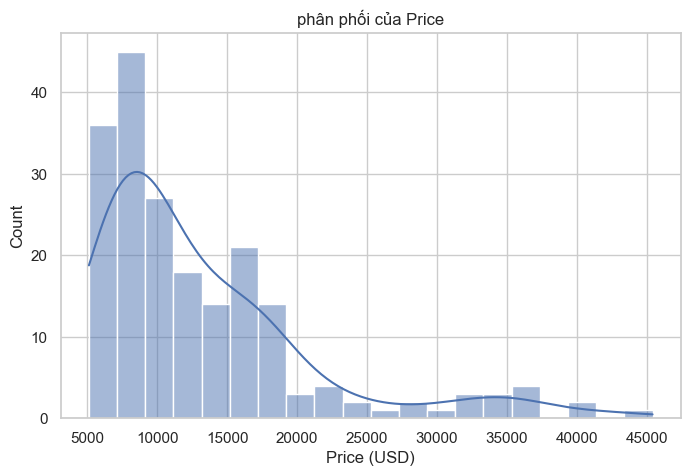

In [52]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(8,5))
sns.histplot(df_clean["price"], bins=20, kde=True)
plt.title("phân phối của Price")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
phân phối bị lệch sang phải , tập trung chủ yếu ở mức giá 5000 đến dưới 20000(USD) . Các giá còn lại phân phối rải rác

## M2.2 Dataset có cân bằng theo body style không?

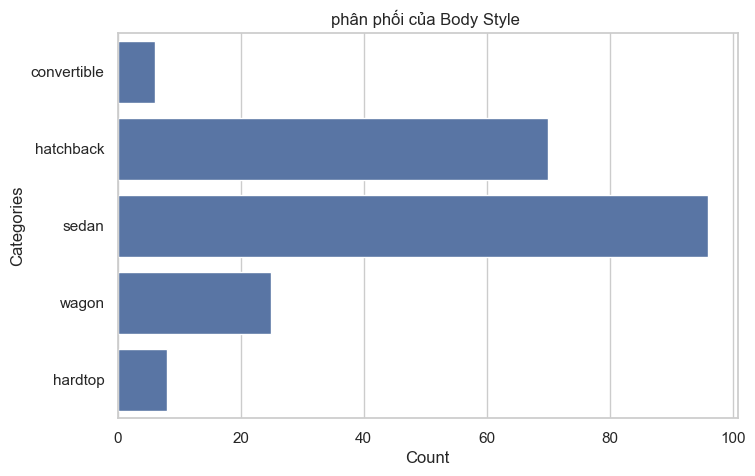

In [53]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(8,5))
sns.countplot(df_clean["body_style"])
plt.title("phân phối của Body Style ")
plt.xlabel("Count")
plt.ylabel("Categories")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Dataset đang không cân bằng theo Body style . Chủ yếu tập trung ở hatchback và sedan rất lớn

## M2.3 Price khác nhau theo body style ra sao?

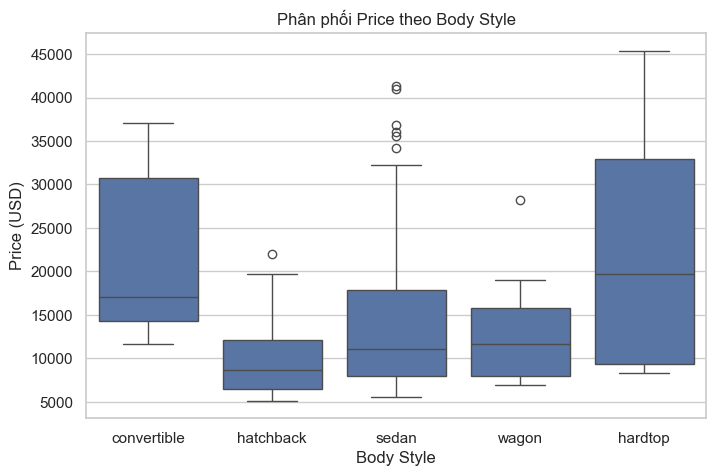

In [56]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x="body_style",y="price")
plt.title("Phân phối Price theo Body Style")
plt.xlabel("Body Style")
plt.ylabel("Price (USD)")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
wagon có phân phối tương đối chuẩn nhất so với các Body Style còn lại . Và sedan có nhiều outlier nhất

## M2.4 Engine size liên quan thế nào tới price?

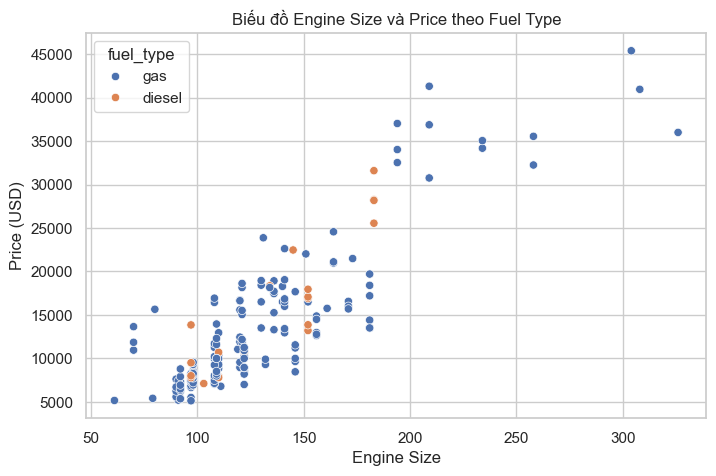

In [58]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x="engine_size",y="price", hue = "fuel_type")
plt.title("Biếu đồ Engine Size và Price theo Fuel Type")
plt.xlabel("Engine Size")
plt.ylabel("Price (USD)")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
+ giá xe có xu hướng tăng khi dung tích động cơ (Engine Size) tăng
+ Xe chạy xăng (gas) xuất hiện nhiều hơn và có mức giá trải rộng hơn, trong khi xe diesel ít hơn nhưng chủ yếu tập trung ở nhóm động cơ và mức giá trung bình đến cao

## M2.5 Các feature numeric tương quan ra sao?

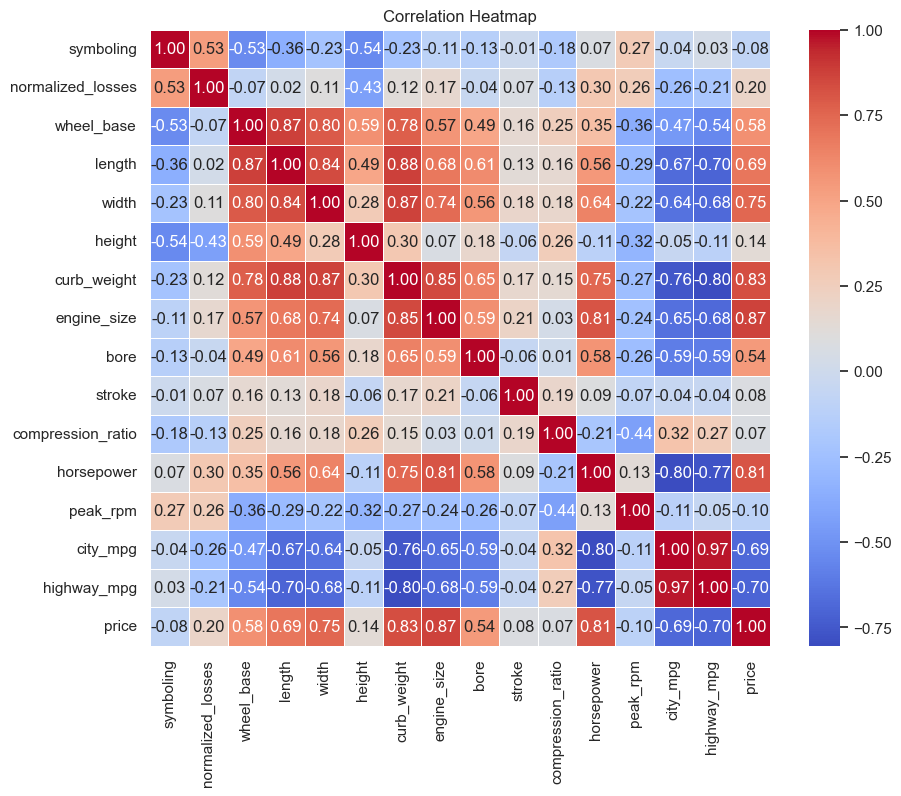

In [59]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(10, 8))
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->  
price tương quan mạnh với engine_size (0.87), curb_weight (0.83) và horsepower (0.81), cho thấy các xe có động cơ lớn và công suất cao thường đắt hơn. Trong khi đó, city_mpg và highway_mpg tương quan âm với price, đồng thời hai biến này tương quan rất cao với nhau (0.97), cho thấy chúng mang thông tin gần như tương đương.


## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

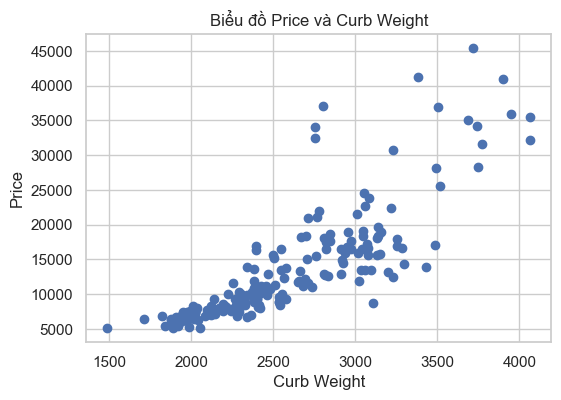

In [61]:
# TODO M2.6: biểu đồ tự chọn
# Xe nặng hơn (curb_weight) có xu hướng đắt hơn (price) không?
plt.figure(figsize=(6,4))
plt.scatter(df_clean["curb_weight"], df_clean["price"])
plt.xlabel("Curb Weight")
plt.ylabel("Price")
plt.title("Biểu đồ Price và Curb Weight")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Có xu hướng xe nặng hơn thường có giá cao hơn, mặc dù vẫn tồn tại một số ngoại lệ.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->
1. 5 phát hiện chính có dẫn chứng  
+ engine_size có tương quan dương mạnh với price, thể hiện qua hệ số tương quan Pearson khá cao. Xe có động cơ lớn thường có giá cao hơn.
+ Giá trung bình khác nhau giữa các body_style. Các dòng convertible và hardtop thường có giá trung bình cao hơn hatchback.
+ Một số cột có dữ liệu bị thiếu, đặc biệt là normalized_losses, trong khi price, horsepower, bore và stroke cũng có một số giá trị thiếu cần xử lý trước khi phân tích.
+ Phân phối price không đồng đều, có một số xe giá rất cao tạo thành các ngoại lệ (outliers).
2. 2 hạn chế của dataset  
Dataset chứa nhiều giá trị thiếu, đặc biệt ở cột normalized_losses, làm giảm độ tin cậy của một số phân tích.
Kích thước dataset không lớn, nên có thể chưa đại diện đầy đủ cho toàn bộ thị trường ô tô và dễ bị ảnh hưởng bởi các ngoại lệ.
3. Một ví dụ về Correlation không đồng nghĩa Causation  
Mặc dù engine_size và price có tương quan cao, không thể kết luận rằng việc tăng kích thước động cơ trực tiếp làm tăng giá xe. Giá xe còn chịu ảnh hưởng bởi nhiều yếu tố khác như thương hiệu (make), công nghệ, trang bị, kiểu thân xe (body_style) và chất lượng sản xuất.
4. Một câu hỏi nên phân tích tiếp  
Thương hiệu (make) ảnh hưởng đến giá xe như thế nào sau khi đã xét đến engine_size và horsepower?